## Unsupervised Learning
#### by **Ivan Alducin**
<p><img src="https://cdn.gritglobal.io/uploads/too-broad-customer-segmentation.jpg" width="1000"/></p>

## Segmentacion de Clientes
<p>En esté capitulo nos vamos a enfocar en entender y trabajar un caso de uso para segmentación de clientes, pero antes de eso aquí una pequeña lista de más aplicaciones que se pueden trabajar con los datos recopliados de mis clientes

- Estadística Descriptiva
- Segmentación de Clientes
- Predicción de Abandono
- Valor del Cliente a traves del tiempo (CTLV)

La segmentación la vamos a hacer con base en una metodolgía llamada <b>RFM</b>

</p>

In [11]:
# Importa Pandas, Numpy, Seaborn y Matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Importa el archivo "Online Retail.csv"
ruta = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 5 Aprendizaje de máquina no supervisado\MOD 5 KNN y Market basket\Proyecto parte 3\M30 Online Retail.csv"
df = pd.read_csv(ruta, encoding='latin1')

In [12]:
# Análisis Exploratorio
df = df[(df['QUANTITY'] > 0) & (df['UNIT_PRICE'] > 0)]
df = df.dropna(subset=['CUSTOMER_ID'])
df['CUSTOMER_ID'] = df['CUSTOMER_ID'].astype(int).astype(str)
df['INVOICE_DATE'] = pd.to_datetime(df['INVOICE_DATE'], dayfirst=True)











## Recency
<p>Indicador que nos dice que tan reciente es la compra de un cliente</p>

In [13]:
# Obtener los clientes unicos
customer = pd.DataFrame(df['CUSTOMER_ID'].unique(), columns=['CUSTOMER_ID'])

In [14]:
# Obtener la última fecha de compra por cliente
max_purchase = df.groupby('CUSTOMER_ID')['INVOICE_DATE'].max().reset_index()

In [15]:
# Vamos a calcular nuestra metrica de Recency, esto lo haremos restando los días de la última fecha de compra a cada observacón
max_date = max_purchase['INVOICE_DATE'].max()
max_purchase['RECENCY'] = (max_date - max_purchase['INVOICE_DATE']).dt.days

In [16]:
# Unir el DataFrame de clientes únicos con el que acabamos de crear de la última fecha de compra
customer = pd.merge(customer, max_purchase[['CUSTOMER_ID', 'RECENCY']], on='CUSTOMER_ID')

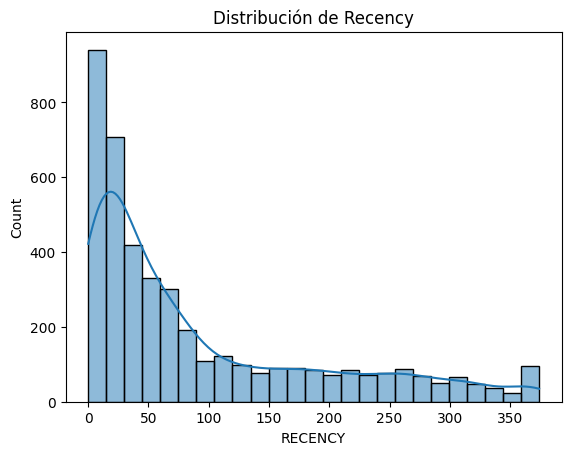

In [17]:
# Grafica un histograma de Recency
sns.histplot(customer['RECENCY'], kde=True)
plt.title('Distribución de Recency')
plt.show()

In [18]:
# Imprime la Estadística de Resumen para Recency
display(customer['RECENCY'].describe())

count    4338.000000
mean       91.610650
std       100.191727
min         0.000000
25%        17.000000
50%        50.000000
75%       141.000000
max       374.000000
Name: RECENCY, dtype: float64

## Frequency
<p>Frecuencia con la que un cliente compra uno o más productos</p>

In [19]:
# Obtener el número de compras por cliente
frequency = df.groupby('CUSTOMER_ID')['INVOICE_DATE'].count().reset_index()
frequency.columns = ['CUSTOMER_ID', 'FREQUENCY']

In [20]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = pd.merge(customer, frequency, on='CUSTOMER_ID')

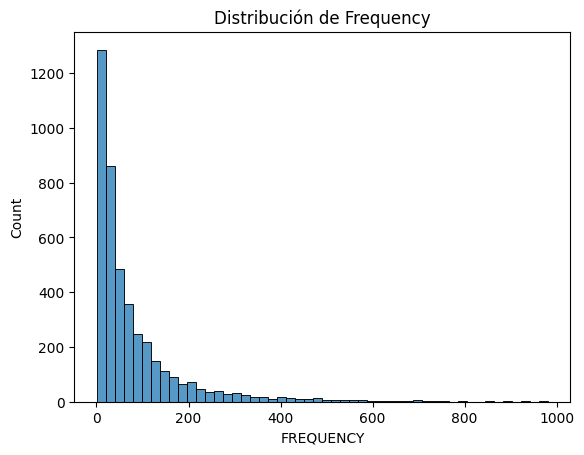

In [21]:
# Grafica un histograma de Frequency
sns.histplot(customer['FREQUENCY'][customer['FREQUENCY'] < 1000], bins=50)
plt.title('Distribución de Frequency')
plt.show()

In [22]:
# Imprime la Estadística de Resumen para Frequency
display(customer['FREQUENCY'].describe())

count    4338.000000
mean       91.720609
std       228.785094
min         1.000000
25%        17.000000
50%        41.000000
75%       100.000000
max      7847.000000
Name: FREQUENCY, dtype: float64

## Monetary
<p>Valor del monto total que ha gastado un cliente en la compra de mis productos</p>

In [23]:
# Calcular el monto total por cada compra
df['MONETARY'] = df['QUANTITY'] * df['UNIT_PRICE']

# Obtener el valor monetario de compra por cliente
monetary = df.groupby('CUSTOMER_ID')['MONETARY'].sum().reset_index()

In [24]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = pd.merge(customer, monetary, on='CUSTOMER_ID')

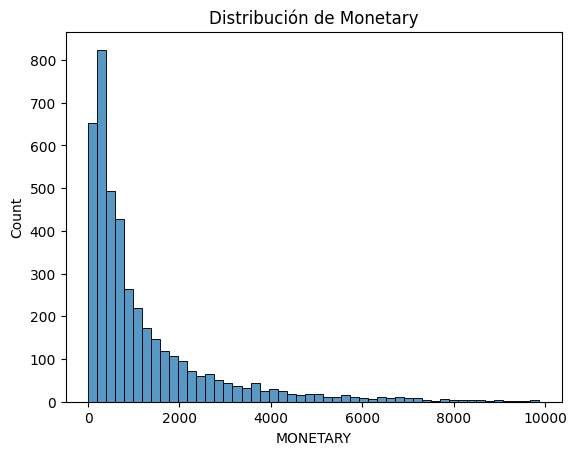

In [25]:
# Grafica un histograma de Monetary
sns.histplot(customer['MONETARY'][customer['MONETARY'] < 10000], bins=50)
plt.title('Distribución de Monetary')
plt.show()

In [26]:
# Imprime la Estadística de Resumen para Monetary
display(customer['MONETARY'].describe())

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: MONETARY, dtype: float64

## Algoritmo k-Means
<p>Ya creamos nuestros indicadores principales de la metodología RFM. es hora de hacer <i>Machine Learning</i>. Para ello utilizaremos un algoritmo no supervisado llamado <b>k-Means</b></p>
<p><img src="https://miro.medium.com/max/818/1*fG8u8nV7qR91wDyFDEEV-g.png" width="250"/></p>

In [27]:
# Funcion para ordenar los clusters
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

## Elbow Method
<p>¿Cual es mi número óptimo de clusters? Vamos a contruir una <i>gráfica de codo</i> para averiguarlo</p>

In [28]:
# Importa la librería de kMeans
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

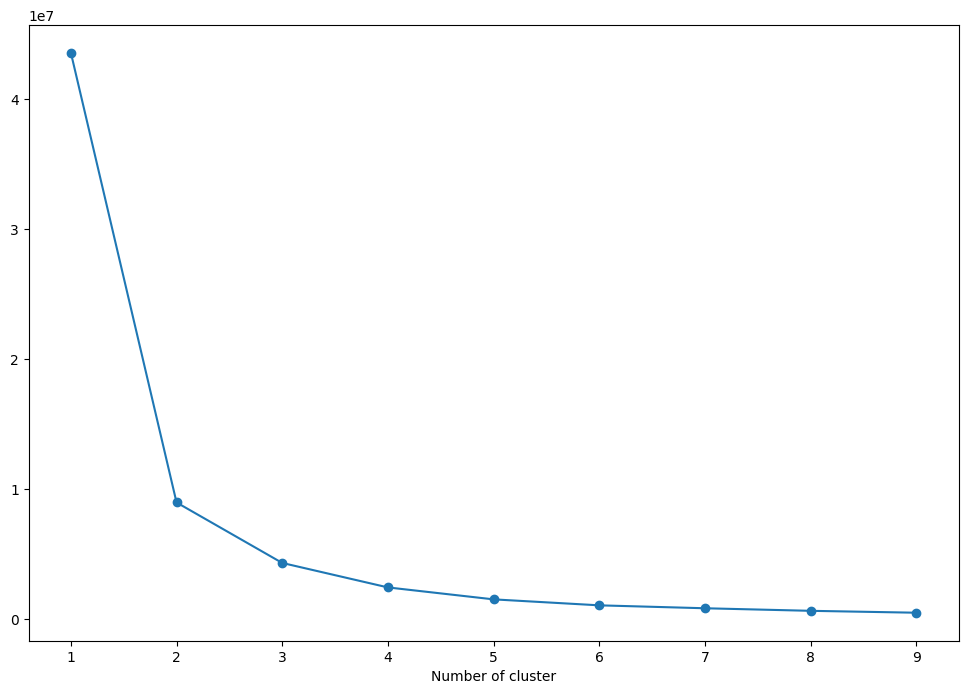

In [29]:
# Configuración inicial - Vamos a tomar como referencia el indicador de Recency
sse={}
recency = customer[['RECENCY']].copy()

for k in range(1, 10):
    # Instancia el algoritmo de k-means iterando sobre k
    kmeans = KMeans(n_clusters=k, max_iter=1000, random_state=42)
    
    # Entrena el algoritmo
    kmeans.fit(recency)
    
    # Adjunta las etiquetas
    recency["clusters"] = kmeans.labels_
    
    # Adunta la inercia o variación al arreglo sse
    sse[k] = kmeans.inertia_
    
# Grafico de codo (Elbow)
plt.figure(figsize=(12,8))
plt.plot(list(sse.keys()), list(sse.values()), marker='o')
plt.xlabel("Number of cluster")
plt.show()

In [30]:
# Instanciar el algoritmo con 4 clusters para Recency 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[['RECENCY']])

# Obtener las predicciones
customer['RECENCY_CLUSTER'] = kmeans.predict(customer[['RECENCY']])

# Ordenar los clusters
customer = order_cluster('RECENCY_CLUSTER', 'RECENCY', customer, False)

# Estadística Descriptiva del cluster creado
display(customer.groupby('RECENCY_CLUSTER')['RECENCY'].describe())

,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,495.0,308.864646,39.284902,252.0,274.00,305.0,337.00,374.0
1,598.0,192.877926,31.602114,140.0,167.25,190.0,217.75,251.0
2,997.0,84.715145,24.050881,53.0,64.00,78.0,103.00,139.0
3,2248.0,19.891904,14.847852,0.0,7.00,17.0,30.00,52.0


In [32]:
# Instanciar el algoritmo con 4 clusters para Monetary 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[['MONETARY']])

# Obtener las predicciones
customer['MONETARY_CLUSTER'] = kmeans.predict(customer[['MONETARY']])

# Ordenar los clusters ¿Como tienes que ordenar el cluster?
customer = order_cluster('MONETARY_CLUSTER', 'MONETARY', customer, True)

# Estadística Descriptiva de los clusters
display(customer.groupby('MONETARY_CLUSTER')['MONETARY'].describe())

,count,mean,std,min,25%,50%,75%,max
MONETARY_CLUSTER,,,,,,,,
0,4300.0,1438.190382,2227.422111,3.75,306.37,664.40,1620.030,21429.39
1,31.0,46393.013871,17870.591823,25977.16,31870.25,40991.57,58668.155,91062.38
2,5.0,149828.502000,31848.698231,117379.63,124914.53,143825.06,168472.500,194550.79
3,2.0,269931.660000,14530.139257,259657.30,264794.48,269931.66,275068.840,280206.02


In [31]:
# Instanciar el algoritmo con 4 clusters para Frequency 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[['FREQUENCY']])

# Obtener las predicciones
customer['FREQUENCY_CLUSTER'] = kmeans.predict(customer[['FREQUENCY']])

# Ordenar los clusters
customer = order_cluster('FREQUENCY_CLUSTER', 'FREQUENCY', customer, True)

# Estadística Descriptiva de los clusters
display(customer.groupby('FREQUENCY_CLUSTER')['FREQUENCY'].describe())

,count,mean,std,min,25%,50%,75%,max
FREQUENCY_CLUSTER,,,,,,,,
0,3830.0,49.093473,43.973616,1.0,15.00,33.0,72.00,185.0
1,480.0,322.641667,131.061480,186.0,220.75,280.5,382.25,799.0
2,24.0,1323.333333,494.664811,851.0,971.50,1128.0,1535.75,2700.0
3,4.0,5807.000000,1429.730044,4595.0,4982.00,5393.0,6218.00,7847.0


## Score de Segmentación
<p>El algoritmo de k-means nos da una segmentación generalizada, pero podemos personalizarla aún más creando una métrica que asigne una calificación al valor del cluster. Esto es lo que vamos a hacer!!</p>

In [33]:
# Vamos a crear nuestro score sumando el valor de cada uno de los clusters
customer['SCORE'] = customer['RECENCY_CLUSTER'] + customer['FREQUENCY_CLUSTER'] + customer['MONETARY_CLUSTER']

# Obtener el promedio para cada una de las métricas de las calificaciones creadas (Score)
display(customer.groupby('SCORE')[['RECENCY', 'FREQUENCY', 'MONETARY']].mean())

,RECENCY,FREQUENCY,MONETARY
SCORE,,,
0,308.707317,22.837398,396.689126
1,193.865093,32.322091,706.694892
2,85.713547,45.439504,1034.596683
3,22.988987,68.762665,1391.657919
4,13.263529,323.487059,5541.339741
5,7.258065,812.225806,27853.593871
6,7.428571,1267.428571,87140.872857
7,2.600000,3876.800000,103382.604000
8,0.500000,3875.500000,212015.540000


In [34]:
# Crea una funcion que asigne lo siguiente: 
# Si score <= 1 entonces 'Low-Value', si score >1 y <=4 entonces 'Average', si score >4 y <=6 entonces 'Potential', por último si score >6 entonces 'High-Value'
def segment(score):
    if score <= 1:
        return 'Low-Value'
    elif score > 1 and score <= 4:
        return 'Average'
    elif score > 4 and score <= 6:
        return 'Potential'
    else:
        return 'High-Value'

# Crear una columna aplicando esta función al campo 'SCORE'
customer['SEGMENT'] = customer['SCORE'].apply(segment)

In [35]:
# Vamos a dar un vistazo a la tabla final
display(customer.head())

,CUSTOMER_ID,RECENCY,FREQUENCY,MONETARY,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER,SCORE,SEGMENT
0,17850,372,297,5391.21,0,1,0,1,Low-Value
1,13047,31,172,3237.54,3,0,0,3,Average
2,12583,2,247,7281.38,3,1,0,4,Average
3,13748,95,28,948.25,2,0,0,2,Average
4,15100,334,3,876.00,0,0,0,0,Low-Value


In [36]:
# Imprime la proporción o el total de clientes por segmento
display(customer['SEGMENT'].value_counts())

SEGMENT
Average       3208
Low-Value     1085
Potential       38
High-Value       7
Name: count, dtype: int64

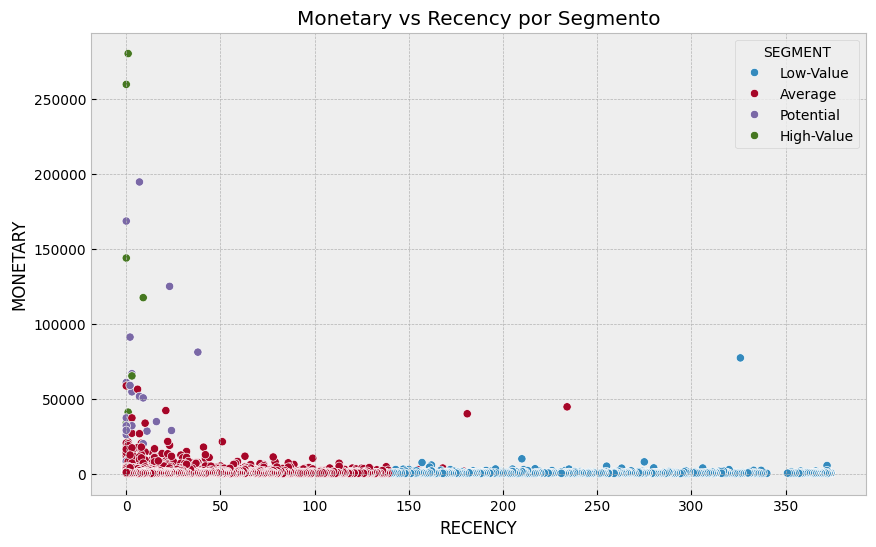

In [37]:
# Define un estilo 'bmh'
plt.style.use('bmh')

# Filtra los valores para RECENCY < 4000
customer_plot = customer[customer['RECENCY'] < 4000]

# Crea un grafico de dispersion de 'MONETARY' VS 'RECENCY' por Segmento
plt.figure(figsize=(10,6))
sns.scatterplot(x='RECENCY', y='MONETARY', hue='SEGMENT', data=customer_plot)
plt.title('Monetary vs Recency por Segmento')
plt.show()

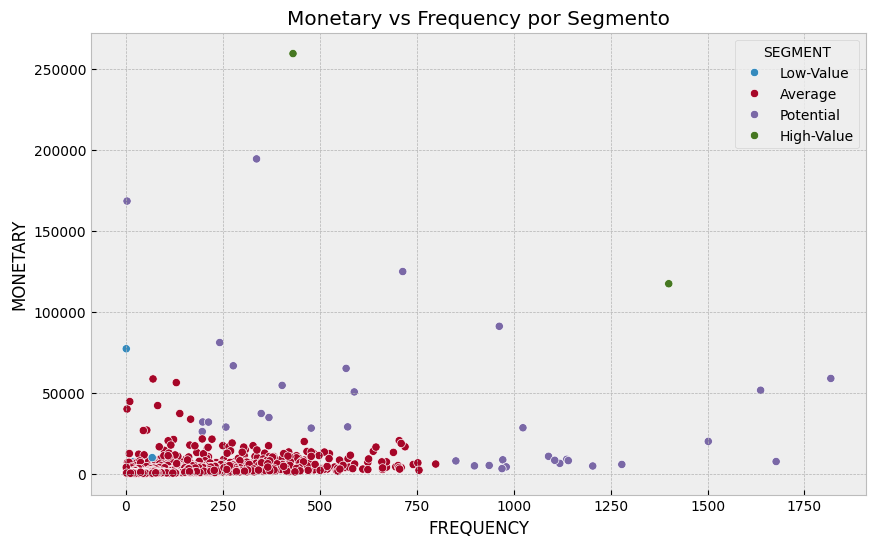

In [38]:
# Crea un grafico de dispersion de 'MONETARY' vs 'FREQUENCY' vs  por Segmento
plt.figure(figsize=(10,6))
sns.scatterplot(x='FREQUENCY', y='MONETARY', hue='SEGMENT', data=customer_plot[customer_plot['FREQUENCY'] < 2000])
plt.title('Monetary vs Frequency por Segmento')
plt.show()